## GDELT dataset

# Extracting GDELT data

We began by working with the GDELT dataset, which publishes event files every 15 minutes. Each file contains events extracted from news sources and other media reports processed during that update cycle. Since the dissertation focuses on Ethiopia, Somalia, Kenya, and South Sudan, we filtered the dataset to retain only events occurring in those countries.

Initially, the intention was to aggregate the data into a daily country-level dataset. However, after evaluating the potential loss of information from aggregation, we decided to retain the data at the event level. This approach preserves the full detail of each event and provides greater flexibility for future analyses.

Although the scope of this work spans between 2015 and 2024, we will begin exploring the data by building a dataset with one year first (2015). We downloaded all GDELT 15 minutes event files for 2015 and extracted the features that would provide relevant information. These include the following:

* GLOBALEVENTID: Unique identifier assigned to each event

* SQLDATE: Date the event occurred

* EventCode: Detailed event type

* EventBaseCode: Simplified version of EventCode

* EventRootCode: Broad event category

* QuadClass: Four broad categories of interaction (1 = Verbal Cooperation , 2 = Material Cooperation , 3 = Verbal conflict, 4 = Material conflict)

* GoldsteinScale: Score from -10 to +10 measuring conflict or cooperation intensity

* NumMentions: Number of times the event was mentioned across monitored media

* NumSources: Number of unique sources reporting the event

* NumArticles: Number of articles mentioning the event

* AvgTone: Average sentiment of reporting

* ActionGeo_FullName: Name of the location where the event occurred

* ActionGeo_CountryCode: Country code of the event location

* ActionGeo_ADM1Code: Administrative region or state code

* ActionGeo_Lat: Latitude of event location

* ActionGeo_Long: Longitude of event location

* SOURCEURL: Original news article URL


Events were filtered to include only those whose event date occurred during 2015. This step was necessary because GDELT files processed in a given year may contain references to events that occurred in earlier years. By filtering on SQLDATE, we ensured that the final dataset contained only events that actually occurred during the study period.

The resulting dataset contains approximately 715,000 individual events across Ethiopia, Somalia, Kenya, and South Sudan for 2015. Each row represents a single event and includes temporal, geographic, thematic, and media-related information. This event-level dataset serves as a master dataset from which daily, monthly, country-level, or district-level indicators can be generated as required for later stages of the analysis.

In [58]:
# STEP 1: Import libraries

import pandas as pd
import requests
import zipfile
from io import BytesIO

In [60]:
# STEP 2: Load GDELT master file list

master_url = "http://data.gdeltproject.org/gdeltv2/masterfilelist.txt"

master = pd.read_csv(
    master_url,
    sep=" ",
    header=None,
    names=["size", "md5", "url"]
)

events = master[
    master["url"].str.contains(".export.CSV.zip", regex=False, na=False)
].copy()

events["datetime"] = events["url"].str.extract(r"(\d{14})")
events = events.dropna(subset=["datetime"]).copy()

events["datetime"] = pd.to_datetime(
    events["datetime"],
    format="%Y%m%d%H%M%S"
)

events.head()

/tmp/ipykernel_870/2070943038.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  master = pd.read_csv(


,size,md5,url,datetime
0,150383,297a16b493de7cf6ca809a7cc31d0b93,http://data.gdeltproject.org/gdeltv2/201502182...,2015-02-18 23:00:00
3,149211,2a91041d7e72b0fc6a629e2ff867b240,http://data.gdeltproject.org/gdeltv2/201502182...,2015-02-18 23:15:00
6,149723,12268e821823aae2da90882621feda18,http://data.gdeltproject.org/gdeltv2/201502182...,2015-02-18 23:30:00
9,158842,a5298ce3c6df1a8a759c61b5c0b6f8bb,http://data.gdeltproject.org/gdeltv2/201502182...,2015-02-18 23:45:00
12,362610,c4268d558bb22c02b3c132c17818c68b,http://data.gdeltproject.org/gdeltv2/201502190...,2015-02-19 00:00:00


In [61]:
# STEP 3: Select 2015 files

year = 2015

year_files = events[
    (events["datetime"] >= f"{year}-01-01") &
    (events["datetime"] < f"{year + 1}-01-01")
].copy()

print("Files found:", len(year_files))
display(year_files.head())

Files found: 30140


,size,md5,url,datetime
0,150383,297a16b493de7cf6ca809a7cc31d0b93,http://data.gdeltproject.org/gdeltv2/201502182...,2015-02-18 23:00:00
3,149211,2a91041d7e72b0fc6a629e2ff867b240,http://data.gdeltproject.org/gdeltv2/201502182...,2015-02-18 23:15:00
6,149723,12268e821823aae2da90882621feda18,http://data.gdeltproject.org/gdeltv2/201502182...,2015-02-18 23:30:00
9,158842,a5298ce3c6df1a8a759c61b5c0b6f8bb,http://data.gdeltproject.org/gdeltv2/201502182...,2015-02-18 23:45:00
12,362610,c4268d558bb22c02b3c132c17818c68b,http://data.gdeltproject.org/gdeltv2/201502190...,2015-02-19 00:00:00


In [62]:
# STEP 4: Define countries and useful columns

COUNTRIES = ["ET", "SO", "KE", "OD"]

USEFUL_COLS = {
    0: "GLOBALEVENTID",
    1: "SQLDATE",
    26: "EventCode",
    27: "EventBaseCode",
    28: "EventRootCode",
    29: "QuadClass",
    30: "GoldsteinScale",
    31: "NumMentions",
    32: "NumSources",
    33: "NumArticles",
    34: "AvgTone",
    52: "ActionGeo_FullName",
    53: "ActionGeo_CountryCode",
    54: "ActionGeo_ADM1Code",
    56: "ActionGeo_Lat",
    57: "ActionGeo_Long",
    60: "SOURCEURL"
}

In [63]:
# STEP 5: Function to process one GDELT file

def process_gdelt_file_event_level(url, year):
    try:
        r = requests.get(url, timeout=60)
        r.raise_for_status()

        with zipfile.ZipFile(BytesIO(r.content)) as z:
            csv_name = z.namelist()[0]

            with z.open(csv_name) as f:
                df = pd.read_csv(
                    f,
                    sep="\t",
                    header=None,
                    low_memory=False
                )

        # Filter to countries of interest
        df = df[df[53].isin(COUNTRIES)].copy()

        if df.empty:
            return pd.DataFrame()

        # Keep useful columns only
        df = df[list(USEFUL_COLS.keys())].copy()
        df = df.rename(columns=USEFUL_COLS)

        # Convert date
        df["Date"] = pd.to_datetime(
            df["SQLDATE"].astype(str),
            format="%Y%m%d",
            errors="coerce"
        )

        # Keep only events that occurred in 2015
        df = df[
            (df["Date"] >= f"{year}-01-01") &
            (df["Date"] < f"{year + 1}-01-01")
        ].copy()

        return df

    except Exception as e:
        print("Failed:", url)
        print(e)
        return pd.DataFrame()

In [64]:
# STEP 6: Process 2015 year

events_2015_list = []

for i, url in enumerate(year_files["url"]):
    if i % 500 == 0:
        print(f"Processing file {i} of {len(year_files)}")

    result = process_gdelt_file_event_level(url, year)

    if not result.empty:
        events_2015_list.append(result)

print("Non-empty files:", len(events_2015_list))

Processing file 0 of 30140
Failed: http://data.gdeltproject.org/gdeltv2/20150219074500.export.CSV.zip
404 Client Error: Not Found for url: http://data.gdeltproject.org/gdeltv2/20150219074500.export.CSV.zip
Failed: http://data.gdeltproject.org/gdeltv2/20150219080000.export.CSV.zip
404 Client Error: Not Found for url: http://data.gdeltproject.org/gdeltv2/20150219080000.export.CSV.zip
Processing file 500 of 30140
Processing file 1000 of 30140


KeyboardInterrupt: 

In [ ]:
# STEP 7: Combine into one 2015 dataset

gdelt_events_2015 = pd.concat(
    events_2015_list,
    ignore_index=True
)

print("Final shape:", gdelt_events_2015.shape)
display(gdelt_events_2015.head())

In [ ]:
# STEP 8: Check the dataset

print("Date range:")
print(gdelt_events_2015["Date"].min())
print(gdelt_events_2015["Date"].max())

print("\nCountry counts:")
print(gdelt_events_2015["ActionGeo_CountryCode"].value_counts())

display(gdelt_events_2015.sample(10))

In [ ]:
# convert code columns to text

gdelt_events_2015["EventCode"] = (
    gdelt_events_2015["EventCode"]
    .astype(str)
)

gdelt_events_2015["EventBaseCode"] = (
    gdelt_events_2015["EventBaseCode"]
    .astype(str)
)

gdelt_events_2015["EventRootCode"] = (
    gdelt_events_2015["EventRootCode"]
    .astype(str)
)

In [ ]:
#Saving CSV file
gdelt_events_2015.to_csv(
    "/content/drive/MyDrive/gdelt_events_2015.csv",
    index=False
)

In [ ]:
gdelt_events_2015 = pd.read_csv(
    "gdelt_events_2015.csv",
    low_memory=False
)

print(gdelt_events_2015.shape)
gdelt_events_2015.head()

In [ ]:
gdelt_events_2015["Date"] = pd.to_datetime(
    gdelt_events_2015["Date"]
)

Plotting the number of events by country
The bar graph below gives us some understanding of how much media coverage each country received. Kenya comes as the country with highest coverage, while South Sudan is the country with the lowest coverage.

In [ ]:
country_names = {
    "ET": "Ethiopia",
    "SO": "Somalia",
    "KE": "Kenya",
    "OD": "South Sudan"
}

country_counts = (
    gdelt_events_2015["ActionGeo_CountryCode"]
    .value_counts()
    .rename(index=country_names)
)

country_counts.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Number of GDELT Events by Country (2015)")
plt.xlabel("Country")
plt.ylabel("Number of Events")
plt.xticks(rotation=0)
plt.show()

# **Understanding Quad Class distribution**

Quad Class serves as event identifier at a broader level.

* QuadClass 1: Verbal Cooperation
Refers to positive interactions expressed through words rather than actions, such as government meetings, peace negotiations and public statements

* QuadClass 2: Positive interactions
involves concrete actions, such as food aid distribution, humanitarian assistance and refugee assistance

* Quadclass 3: Verbal Conflict
Negative interactions expressed through words, such as public accusations, threats and political disputes

* Quadclass 4: Material Conflict
Physical conflict or coercive actions, such as terrorist attacks, military operations and distruction of infrastructure


In [ ]:
quad_counts = (
    gdelt_events_2015["QuadClass"]
    .value_counts()
    .sort_index()
)

quad_labels = {
    1: "Verbal Cooperation",
    2: "Material Cooperation",
    3: "Verbal Conflict",
    4: "Material Conflict"
}

quad_counts.index = [
    quad_labels[i] for i in quad_counts.index
]

quad_counts.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Distribution of QuadClass Events (2015)")
plt.xlabel("QuadClass")
plt.ylabel("Number of Events")
plt.xticks(rotation=20)
plt.show()

# **Quad Class distribution by country**

In [ ]:
quad_country = pd.crosstab(
    gdelt_events_2015["ActionGeo_CountryCode"],
    gdelt_events_2015["QuadClass"]
)

quad_country.columns = [
    "Verbal Cooperation",
    "Material Cooperation",
    "Verbal Conflict",
    "Material Conflict"
]

quad_country

,Verbal Cooperation,Material Cooperation,Verbal Conflict,Material Conflict
ActionGeo_CountryCode,,,,
ET,81834,14099,13717,14747
KE,211287,34000,47858,50884
OD,42008,7423,10655,16114
SO,88218,17774,19827,44284


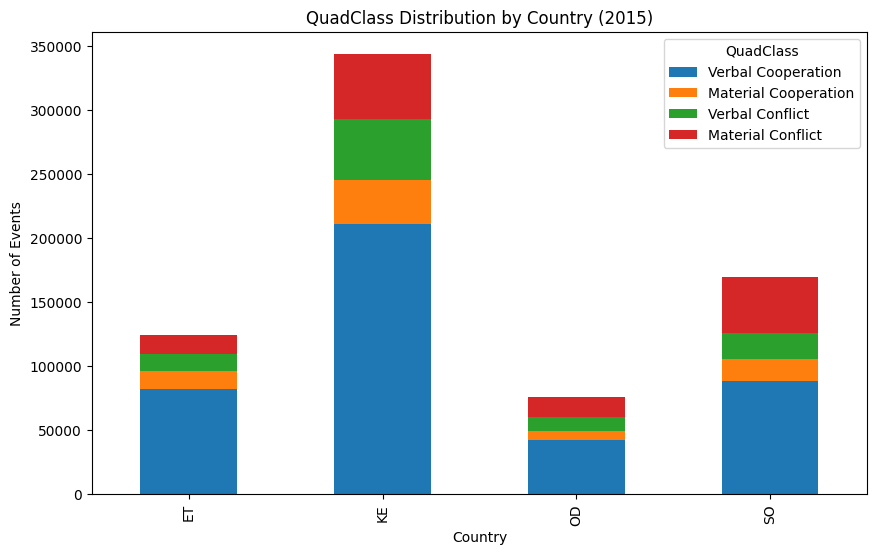

In [ ]:
quad_country = pd.crosstab(
    gdelt_events_2015["ActionGeo_CountryCode"],
    gdelt_events_2015["QuadClass"]
)

quad_country.columns = [
    "Verbal Cooperation",
    "Material Cooperation",
    "Verbal Conflict",
    "Material Conflict"
]

quad_country.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("QuadClass Distribution by Country (2015)")
plt.xlabel("Country")
plt.ylabel("Number of Events")
plt.legend(title="QuadClass")
plt.show()

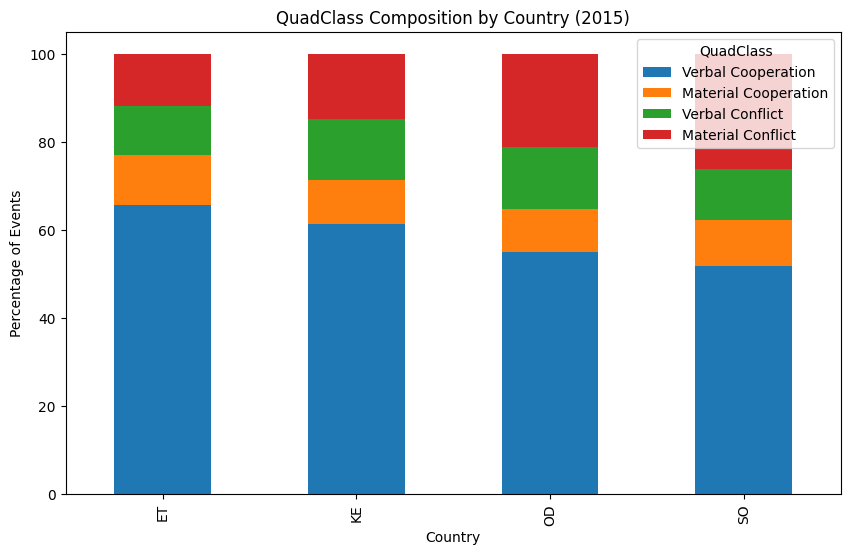

In [ ]:
quad_country_pct = pd.crosstab(
    gdelt_events_2015["ActionGeo_CountryCode"],
    gdelt_events_2015["QuadClass"],
    normalize="index"
) * 100

quad_country_pct.columns = [
    "Verbal Cooperation",
    "Material Cooperation",
    "Verbal Conflict",
    "Material Conflict"
]

quad_country_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("QuadClass Composition by Country (2015)")
plt.xlabel("Country")
plt.ylabel("Percentage of Events")
plt.legend(title="QuadClass")
plt.show()

 The majority of events across all four countries were classified as Verbal Cooperation, indicating that news related to diplomatic statements, consultations, and public communications are dominant within international news reporting. However, Somalia and South Sudan exhibited a noticeably higher proportion of Material Conflict and Verbal Conflict events compared to Ethiopia and Kenya. This suggests that conflict-related reporting constitutes a larger share of media activity in these countries and may provide useful signals for monitoring conditions associated with food insecurity.

 While this analysis provides a broad overview, QuadClass remains a high-level classification. Further investigation of more detailed event categories, such as aid provision, protests, assaults, and fighting, may offer a deeper understanding of how specific events relate to food insecurity and humanitarian conditions in the region.

# EventRootCode Legend
After having explored Quad Class classification, we will now be looking into EventRootCode, which provides a more specific classification.

EventRootCode can fall into one of the following types:

- **01 – Public Statement**
  - Statements, comments, announcements, declarations, speeches, or public communications.

- **02 – Appeal**
  - Requests for assistance, mediation, support, resources, or action.

- **03 – Intent to Cooperate**
  - Expressions of willingness or plans to cooperate in the future.

- **04 – Consult**
  - Meetings, negotiations, discussions, consultations, or diplomatic talks.

- **05 – Diplomatic Cooperation**
  - Formal diplomatic agreements, partnerships, and cooperative arrangements.

- **06 – Material Cooperation**
  - Practical cooperation involving resources, services, or actions.

- **07 – Provide Aid**
  - Humanitarian assistance, food aid, financial support, relief operations, or development assistance.

- **08 – Yield**
  - Concessions, compromises, compliance, surrender, or acceptance of demands.

- **09 – Investigate**
  - Assessments, inspections, monitoring, investigations, evaluations, or fact-finding missions.

- **10 – Demand**
  - Demands for action, policy changes, resources, rights, or concessions.

- **11 – Disapprove**
  - Criticism, condemnation, complaints, or expressions of dissatisfaction.

- **12 – Reject**
  - Refusal of proposals, agreements, requests, negotiations, or recommendations.

- **13 – Threaten**
  - Warnings, threats, or indications of potential future hostile action.

- **14 – Protest**
  - Demonstrations, strikes, public protests, rallies, or organized opposition.

- **15 – Exhibit Force Posture**
  - Military exercises, troop deployments, military mobilization, or shows of force.

- **16 – Reduce Relations**
  - Sanctions, restrictions, diplomatic downgrades, embargoes, or reduced cooperation.

- **17 – Coerce**
  - Attempts to force compliance through pressure, intimidation, or coercive measures.

- **18 – Assault**
  - Physical attacks, assaults, kidnappings, raids, or violent incidents.

- **19 – Fight**
  - Armed clashes, battles, military engagements, or combat operations.

- **20 – Use Unconventional Mass Violence**
  - Terrorist attacks, mass killings, ethnic violence, atrocities, or large-scale violence.

In [ ]:
root_counts = (
    gdelt_events_2015["EventRootCode"]
    .value_counts()
    .sort_index()
)

root_counts

,count
EventRootCode,
1,90077
2,45252
3,48381
4,184842
5,54795
6,14520
7,25212
8,24018
9,9546


In [ ]:
root_labels = {
    "01": "Public Statement",
    "02": "Appeal",
    "03": "Intent to Cooperate",
    "04": "Consult",
    "05": "Diplomatic Cooperation",
    "06": "Material Cooperation",
    "07": "Provide Aid",
    "08": "Yield",
    "09": "Investigate",
    "10": "Demand",
    "11": "Disapprove",
    "12": "Reject",
    "13": "Threaten",
    "14": "Protest",
    "15": "Exhibit Force Posture",
    "16": "Reduce Relations",
    "17": "Coerce",
    "18": "Assault",
    "19": "Fight",
    "20": "Mass Violence"
}

In [ ]:
root_summary = (
    gdelt_events_2015["EventRootCode"]
    .value_counts()
    .reset_index()
)

root_summary.columns = ["EventRootCode", "Count"]

# Convert to 2-digit strings
root_summary["EventRootCode"] = (
    root_summary["EventRootCode"]
    .astype(str)
    .str.zfill(2)
)

# Add descriptions
root_summary["Description"] = (
    root_summary["EventRootCode"]
    .map(root_labels)
)

# Sort numerically by EventRootCode
root_summary = root_summary.sort_values(
    by="EventRootCode"
).reset_index(drop=True)

root_summary

,EventRootCode,Count,Description
0,01,90077,Public Statement
1,02,45252,Appeal
2,03,48381,Intent to Cooperate
3,04,184842,Consult
4,05,54795,Diplomatic Cooperation
5,06,14520,Material Cooperation
6,07,25212,Provide Aid
7,08,24018,Yield
8,09,9546,Investigate
9,10,10230,Demand


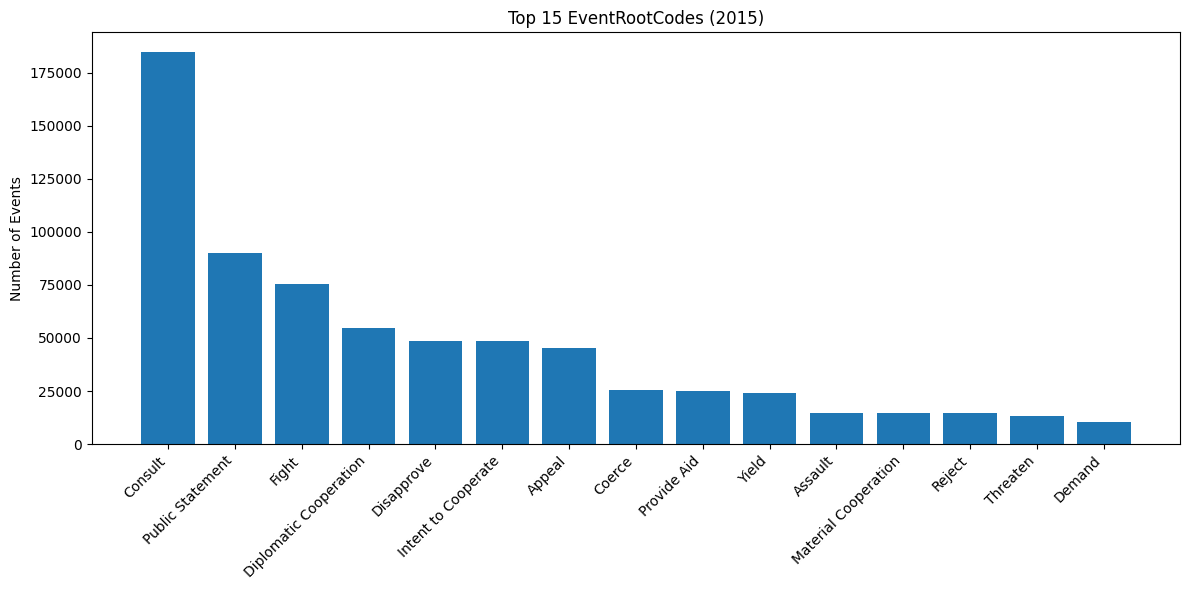

In [ ]:
import matplotlib.pyplot as plt

top15 = root_summary.head(15)

plt.figure(figsize=(12,6))

plt.bar(
    top15["Description"],
    top15["Count"]
)

plt.xticks(rotation=45, ha="right")
plt.title("Top 15 EventRootCodes (2015)")
plt.ylabel("Number of Events")
plt.tight_layout()

plt.show()

In [ ]:
root_country = pd.crosstab(
    gdelt_events_2015["ActionGeo_CountryCode"],
    gdelt_events_2015["EventRootCode"]
)

root_country

EventRootCode,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
ActionGeo_CountryCode,,,,,,,,,,,,,,,,,,,,
ET,14428,6833,10357,37760,12456,3367,4997,4409,1326,1262,6836,2418,1453,1748,279,910,5071,1781,6616,90
KE,45530,24466,27193,90844,23254,6849,11813,10071,5267,5678,25507,7138,7211,2324,1512,2341,11959,5893,28597,582
OD,9022,5217,3997,16579,7193,1402,2413,2781,827,1231,5715,2019,1183,507,453,1153,1759,1944,10577,228
SO,21097,8736,6834,39659,11892,2902,5989,6757,2126,2059,10489,2852,3522,905,1012,1374,6621,5098,29884,295


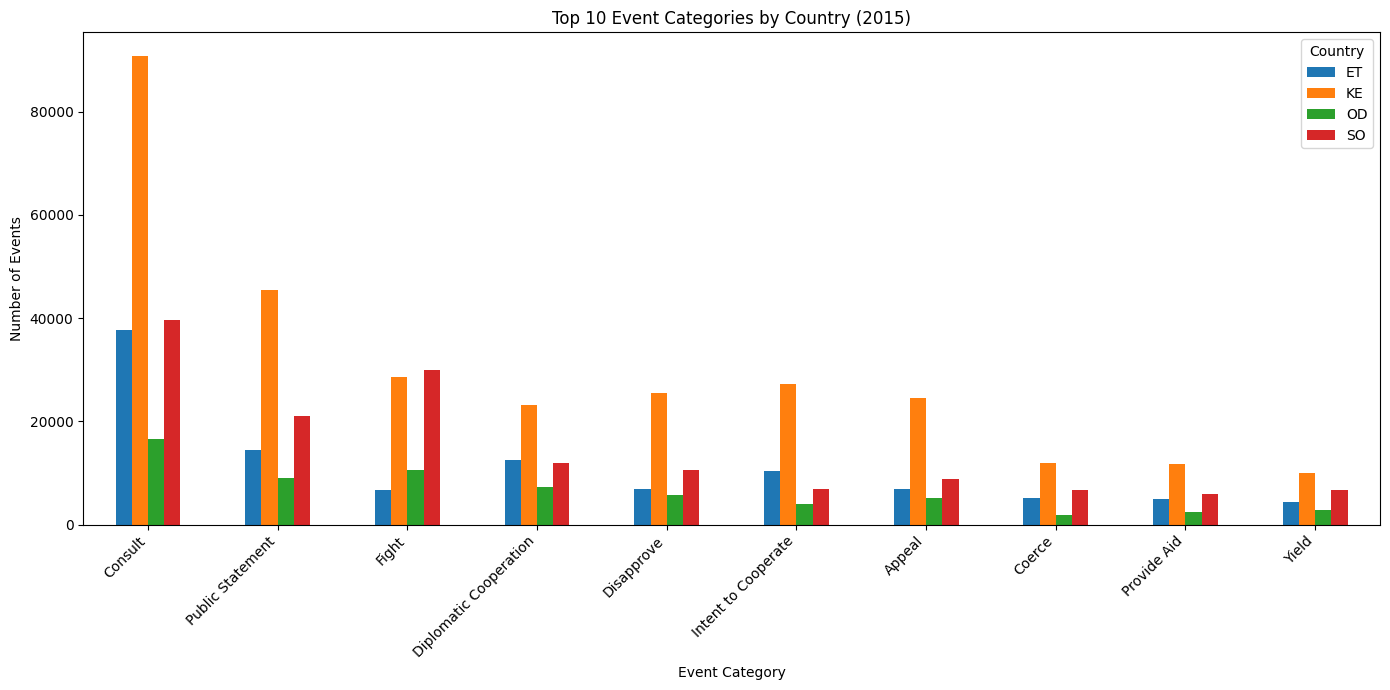

In [ ]:
# Top 10 EventRootCodes

top_codes = (
    gdelt_events_2015["EventRootCode"]
    .astype(str)
    .str.zfill(2)
    .value_counts()
    .head(10)
    .index
)

# Cross-tab by country and EventRootCode

top_root_country = pd.crosstab(
    gdelt_events_2015["ActionGeo_CountryCode"],
    gdelt_events_2015["EventRootCode"]
    .astype(str)
    .str.zfill(2)
)

top_root_country = top_root_country[top_codes]

# Replace code numbers with descriptions

top_root_country.columns = [
    root_labels.get(code, code)
    for code in top_root_country.columns
]

# Plot

top_root_country.T.plot(
    kind="bar",
    figsize=(14,7)
)

plt.title("Top 10 Event Categories by Country (2015)")
plt.ylabel("Number of Events")
plt.xlabel("Event Category")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Country")
plt.tight_layout()
plt.show()

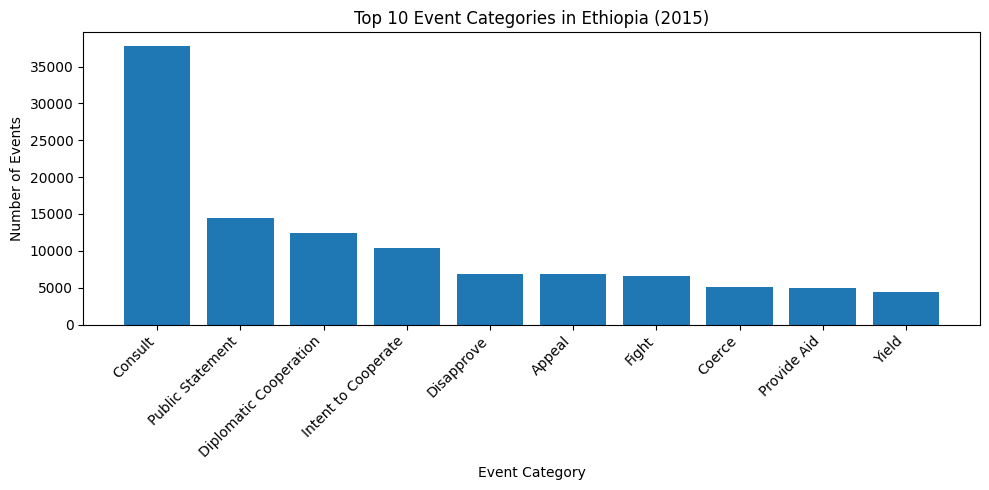

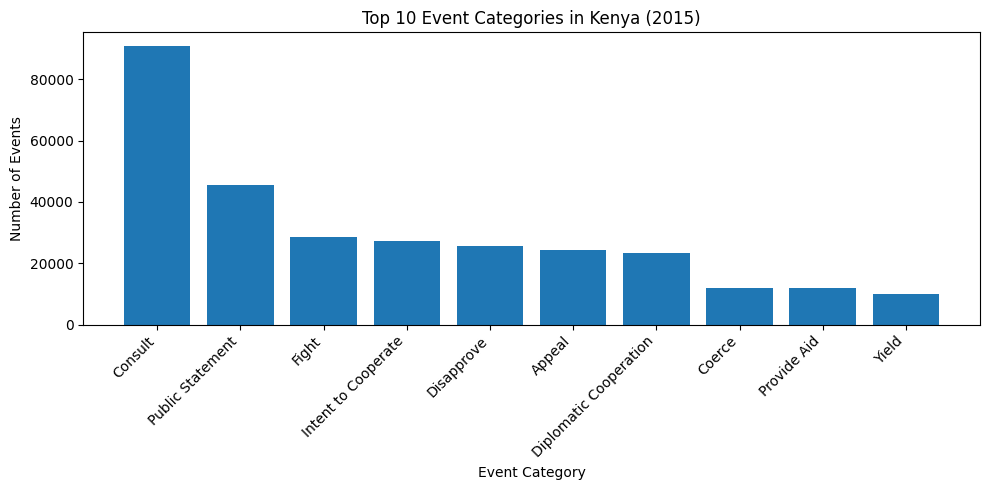

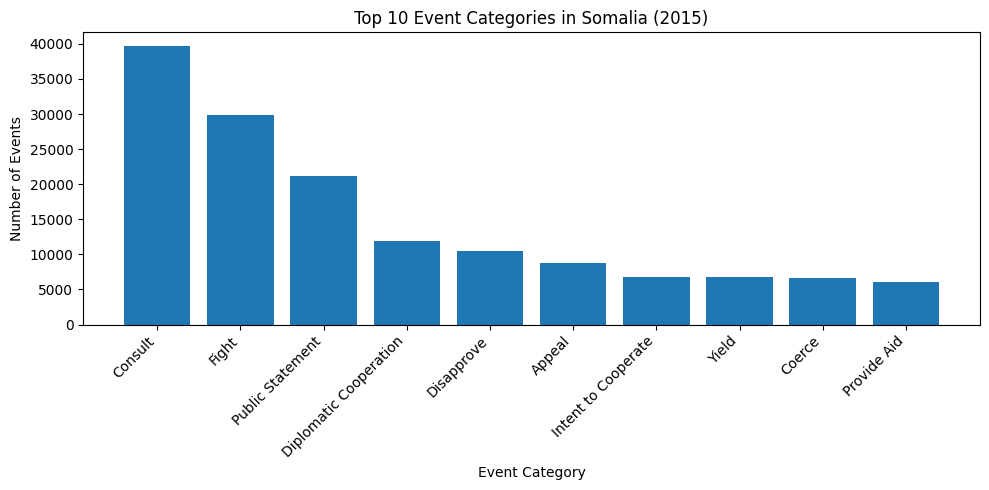

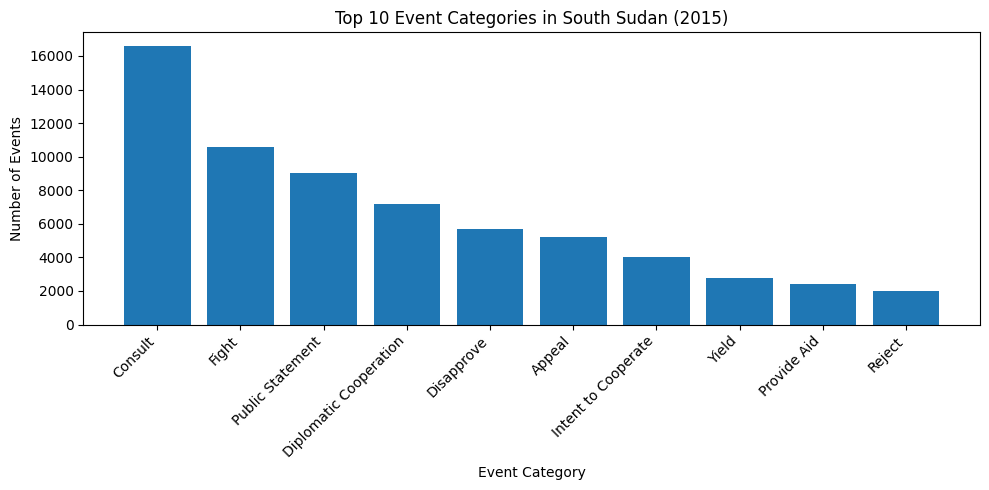

In [ ]:
import matplotlib.pyplot as plt

countries = {
    "ET": "Ethiopia",
    "KE": "Kenya",
    "SO": "Somalia",
    "OD": "South Sudan"
}

for country_code, country_name in countries.items():

    country_data = gdelt_events_2015[
        gdelt_events_2015["ActionGeo_CountryCode"] == country_code
    ]

    top10 = (
        country_data["EventRootCode"]
        .astype(str)
        .str.zfill(2)
        .value_counts()
        .head(10)
    )

    labels = [
        root_labels.get(code, code)
        for code in top10.index
    ]

    plt.figure(figsize=(10,5))

    plt.bar(labels, top10.values)

    plt.title(f"Top 10 Event Categories in {country_name} (2015)")
    plt.ylabel("Number of Events")
    plt.xlabel("Event Category")

    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

The EventRootCode analysis provides a more detailed understanding of the types of events being captured by GDELT across Ethiopia, Kenya, Somalia, and South Sudan in 2015. While the previous QuadClass analysis showed a broad distinction between cooperation and conflict, EventRootCodes reveal the specific activities driving those patterns.

The most common event category across the dataset was Consult (04), followed by Public Statement (01). These categories represent meetings, negotiations, discussions, diplomatic engagements, and public communications. Their prominence suggests that a large proportion of media coverage in the region focuses on political dialogue, government activity, international relations, and humanitarian coordination rather than solely on crises or violence. This finding highlights one of the strengths of GDELT, as it captures both routine interactions and major events.

Despite the dominance of cooperative and diplomatic activities, conflict-related events remain highly prominent. Fight (19) was the third most common EventRootCode across the four countries, indicating that armed clashes and military engagements were a significant feature of reporting during 2015. Additional conflict-related categories such as Coerce (17), Assault (18), Threaten (13), and Disapprove (11) also appear among the most frequent event types. Together, these categories suggest that political instability and violent conflict were major themes within the dataset.

From a food insecurity perspective, the presence of a large number of conflict-related events is particularly important. Conflict is widely recognised as one of the main drivers of food insecurity in the Horn of Africa, as it can disrupt agricultural production, damage infrastructure, restrict access to markets, hinder humanitarian operations, and force population displacement. The prominence of conflict-related EventRootCodes therefore suggests that GDELT may capture signals associated with conditions that contribute to worsening food security outcomes.

The analysis also shows a substantial number of Appeal (02) and Provide Aid (07) events. Unlike conflict events, these categories are not necessarily drivers of food insecurity but may instead represent responses to emerging humanitarian needs. Appeals often indicate that governments, NGOs, or international organisations are requesting assistance, while aid events reflect the delivery of humanitarian support. As a result, these categories may provide useful indicators of humanitarian response activity and could potentially be used to identify periods or locations experiencing heightened vulnerability.

Looking at individual countries, Kenya appears to have a stronger emphasis on consultation, public statements, and cooperative activities, reflecting a relatively larger share of political and diplomatic reporting. In contrast, Somalia and South Sudan are expected to exhibit a higher concentration of conflict-related events, consistent with the security challenges faced by both countries during the study period. These differences suggest that the composition of EventRootCodes may provide meaningful information about the underlying conditions within each country and could help explain variations in food security outcomes across the region.

Overall, the EventRootCode analysis demonstrates that GDELT captures a diverse range of activities, including diplomacy, humanitarian response, social tensions, and violent conflict. This diversity is valuable for the dissertation because it provides multiple pathways through which news-based event data may be linked to food insecurity. Rather than relying on a single indicator, future analysis can explore how combinations of conflict, aid, protest, and cooperation events relate to food security conditions measured by IPC classifications and other humanitarian indicators.

A next step would be comparing results from RootEvent codes against IPC phases to understand if there is any relationship between the two

#Understanding Goldsteinscale and AvgTone

We will look into these two variables, which tell us some important details:

* AvgTone	"How positive or negative is the news reporting?
This focuses on the language of the reporting, acting in a similar way to sentiment analysis. It scores news on a scale from very negative (-100) to very positive (100)


* GoldsteinScale	"How cooperative or conflictual are the events themselves?"
This metric gives a numeric value to EventRootCodes, classifying events on a scal from cooperative to conflictual. In other words, this measures how positive or negative was the event itself

In [ ]:
#Year average for tone
tone_country = (
    gdelt_events_2015
    .groupby("ActionGeo_CountryCode")["AvgTone"]
    .agg(["mean","median","min","max"])
    .round(2)
)

tone_country

,mean,median,min,max
ActionGeo_CountryCode,,,,
ET,-1.81,-1.56,-26.44,13.74
KE,-2.79,-2.65,-24.51,16.34
OD,-3.49,-3.61,-18.92,13.33
SO,-4.29,-4.30,-20.75,17.09


In [ ]:
# Year average for GoldsteinScale
gold_country = (
    gdelt_events_2015
    .groupby("ActionGeo_CountryCode")["GoldsteinScale"]
    .agg(["mean","median","min","max"])
    .round(2)
)

gold_country

,mean,median,min,max
ActionGeo_CountryCode,,,,
ET,1.17,1.9,-10.0,10.0
KE,0.33,1.9,-10.0,10.0
OD,-0.25,1.0,-10.0,10.0
SO,-0.87,0.4,-10.0,10.0


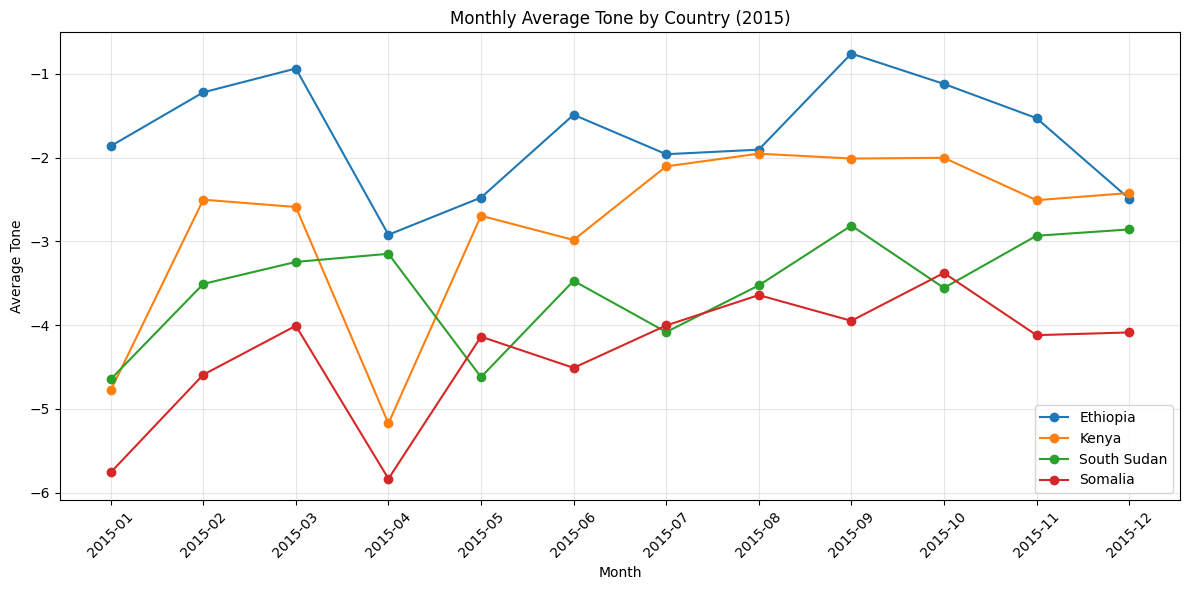

In [ ]:
#Average tone monthly trend
import matplotlib.pyplot as plt

# Create Month column if needed
gdelt_events_2015["Month"] = (
    gdelt_events_2015["Date"]
    .dt.to_period("M")
    .astype(str)
)

monthly_tone = (
    gdelt_events_2015
    .groupby(["Month", "ActionGeo_CountryCode"])["AvgTone"]
    .mean()
    .unstack()
)

# Rename countries
monthly_tone = monthly_tone.rename(columns={
    "ET": "Ethiopia",
    "KE": "Kenya",
    "SO": "Somalia",
    "OD": "South Sudan"
})

plt.figure(figsize=(12,6))

for country in monthly_tone.columns:
    plt.plot(
        monthly_tone.index,
        monthly_tone[country],
        marker="o",
        label=country
    )

plt.title("Monthly Average Tone by Country (2015)")
plt.xlabel("Month")
plt.ylabel("Average Tone")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

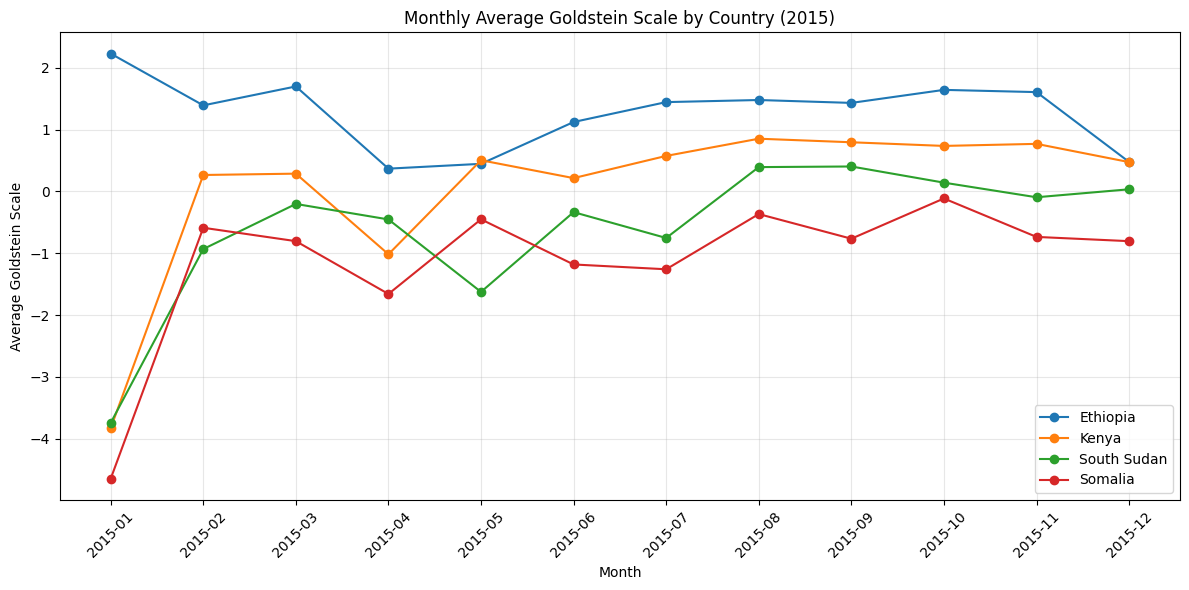

In [ ]:
#Average Goldstein monthly trend
monthly_gold = (
    gdelt_events_2015
    .groupby(["Month", "ActionGeo_CountryCode"])["GoldsteinScale"]
    .mean()
    .unstack()
)

monthly_gold = monthly_gold.rename(columns={
    "ET": "Ethiopia",
    "KE": "Kenya",
    "SO": "Somalia",
    "OD": "South Sudan"
})

plt.figure(figsize=(12,6))

for country in monthly_gold.columns:
    plt.plot(
        monthly_gold.index,
        monthly_gold[country],
        marker="o",
        label=country
    )

plt.title("Monthly Average Goldstein Scale by Country (2015)")
plt.xlabel("Month")
plt.ylabel("Average Goldstein Scale")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The analysis revealed clear differences between countries in both AvgTone and Goldstein Scale. Ethiopia exhibited the highest average Goldstein score (+1.17) and the least negative average tone (-1.81), suggesting that reported events were generally more cooperative and that media coverage was comparatively less negative. In contrast, Somalia displayed the lowest average Goldstein score (-0.87) and the most negative average tone (-4.29), indicating a more conflict-oriented event environment accompanied by more negative reporting. South Sudan showed a similar but less pronounced pattern, while Kenya occupied an intermediate position between Ethiopia and the more conflict-affected countries. These findings are consistent with the EventRootCode and QuadClass analyses, which showed higher proportions of conflict-related events in Somalia and South Sudan. Together, the results suggest that Goldstein Scale and AvgTone may provide useful summary indicators of the broader conditions captured by news-based datasets and could potentially contribute to food insecurity monitoring when combined with IPC, rainfall, and other contextual indicators

# CHIRPS data (rainfall)

In [68]:
# STEP 1: Create folder
import os
os.makedirs("chirps_monthly", exist_ok=True)

In [69]:
# STEP 2: Download CHIRPS monthly rainfall files, 2015-2024

base_url = "https://data.chc.ucsb.edu/products/CHIRPS-2.0/global_monthly/tifs"

for year in range(2015, 2025):
    for month in range(1, 13):
        file_name = f"chirps-v2.0.{year}.{month:02d}.tif.gz"
        url = f"{base_url}/{file_name}"

        print("Downloading:", file_name)
        !wget -q --show-progress -P chirps_monthly "{url}"

Downloading: chirps-v2.0.2015.01.tif.gz
Downloading: chirps-v2.0.2015.02.tif.gz
Downloading: chirps-v2.0.2015.03.tif.gz
Downloading: chirps-v2.0.2015.04.tif.gz
Downloading: chirps-v2.0.2015.05.tif.gz
Downloading: chirps-v2.0.2015.06.tif.gz
Downloading: chirps-v2.0.2015.07.tif.gz
Downloading: chirps-v2.0.2015.08.tif.gz
Downloading: chirps-v2.0.2015.09.tif.gz
Downloading: chirps-v2.0.2015.10.tif.gz
Downloading: chirps-v2.0.2015.11.tif.gz
Downloading: chirps-v2.0.2015.12.tif.gz
Downloading: chirps-v2.0.2016.01.tif.gz
Downloading: chirps-v2.0.2016.02.tif.gz
Downloading: chirps-v2.0.2016.03.tif.gz
Downloading: chirps-v2.0.2016.04.tif.gz
Downloading: chirps-v2.0.2016.05.tif.gz
Downloading: chirps-v2.0.2016.06.tif.gz
Downloading: chirps-v2.0.2016.07.tif.gz
Downloading: chirps-v2.0.2016.08.tif.gz
Downloading: chirps-v2.0.2016.09.tif.gz
Downloading: chirps-v2.0.2016.10.tif.gz
Downloading: chirps-v2.0.2016.11.tif.gz
Downloading: chirps-v2.0.2016.12.tif.gz
Downloading: chirps-v2.0.2017.01.tif.gz
